# 🧹 Credit Risk — Data Cleaning

## 📌 Project Overview

This notebook focuses exclusively on the **data cleaning process** for the Credit Risk dataset.  
The objective is to prepare a reliable and consistent dataset before performing exploratory analysis or predictive modeling.

The cleaning workflow includes:

- Handling missing values
- Checking for duplicates
- Correcting inconsistent data types
- Validating data quality
<!-- - Detecting outliers -->


## 📚 Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import math
warnings.filterwarnings("ignore")

## 📂 Load Dataset

In [2]:
# data import
path = Path("Data")
data = pd.read_csv(path / "cs-training.csv") 
df = data.copy()

**Dataset:** *Give Me Some Credit* (Kaggle Credit Risk Dataset)

| Original Column Name                  | Simplified Name     | Description |
|--------------------------------------|---------------------|-------------|
| SeriousDlqin2yrs                     | Default Status      | Binary variable indicating whether the borrower experienced financial distress and failed to pay debt for more than 90 days (1 = Yes, 0 = No) |
| RevolvingUtilizationOfUnsecuredLines | Credit Usage %      | Percentage of available unsecured credit currently being used |
| age                                  | Age                 | Borrower’s age in years |
| NumberOfTime30-59DaysPastDueNotWorse | 30–59 Days Late     | Number of times the borrower was 30–59 days past due |
| DebtRatio                            | Debt-to-Income      | Monthly debt payments and expenses divided by total monthly income |
| MonthlyIncome                        | Monthly Income      | Borrower’s gross monthly income |
| NumberOfOpenCreditLinesAndLoans      | Open Credit Accounts| Total number of active credit cards and loans |
| NumberOfTimes90DaysLate              | 90+ Days Late       | Number of times the borrower was 90 or more days past due |
| NumberRealEstateLoansOrLines         | Real Estate Loans   | Number of mortgage loans or real estate credit lines |
| NumberOfTime60-89DaysPastDueNotWorse | 60–89 Days Late     | Number of times the borrower was 60–89 days past due |
| NumberOfDependents                   | Dependents          | Number of dependents supported by the borrower (children, spouse, others) |

## 🔎 Initial Inspection

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Df description before cleaning
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

The dataset contains 150,000 observations and 12 variables, combining both demographic and financial information related to borrowers. Most variables are stored as numerical data types, including 8 integer variables and 4 floating-point variables

### Duplicateds


In this section, we verify whether duplicate records exist in the dataset.

In [6]:
df.duplicated().sum()

np.int64(0)

The dataset does not contain any duplicated value.

### Distribution of the numeric variables

The following visualizations provide an overview of the main numerical predictors, helping identify abnormal patterns, concentration effects, and potential preprocessing requirements.

In [7]:
def plot_numeric_distributions(
    df,
    target_column=None,
    percentile=0.99,
    n_cols=3,
    bins=30,
    figsize_per_row=5,
    palette="Set2"
):
    """
    Plot numerical variable distributions applying
    upper clipping at a selected percentile.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    target_column : str, optional
        Target column to exclude from plots.

    percentile : float, default=0.99
        Percentile used for upper clipping.

    n_cols : int, default=3
        Number of subplot columns.

    bins : int, default=30
        Number of histogram bins.

    figsize_per_row : int, default=5
        Height per subplot row.

    palette : str, default='Set2'
        Seaborn color palette.
    """

    # -----------------------------------
    # Copy dataframe and select variables
    # -----------------------------------
    df_plot = df.copy()

    if target_column and target_column in df_plot.columns:
        df_plot = df_plot.drop(columns=[target_column])

    numeric_columns = df_plot.select_dtypes(
        include=["int64", "float64"]
    ).columns

    # -----------------------------------
    # Apply percentile clipping
    # -----------------------------------
    percentile_values = {}

    for col in numeric_columns:
        p_value = df_plot[col].quantile(percentile)
        percentile_values[col] = p_value
        df_plot[col] = df_plot[col].clip(upper=p_value)

    # -----------------------------------
    # Plot configuration
    # -----------------------------------
    sns.set_style("whitegrid")
    sns.set_context("notebook")

    n_rows = math.ceil(len(numeric_columns) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, figsize_per_row * n_rows)
    )

    axes = axes.flatten()

    colors = sns.color_palette(palette, len(numeric_columns))

    # -----------------------------------
    # Plot distributions
    # -----------------------------------
    for i, col in enumerate(numeric_columns):

        sns.histplot(
            df_plot[col],
            bins=bins,
            kde=True,
            ax=axes[i],
            color=colors[i],
            edgecolor="black",
            alpha=0.75
        )

        axes[i].set_title(
            f"{col}\n(visual clipping at p{int(percentile * 100)} = "
            f"{percentile_values[col]:,.2f})",
            fontsize=12,
            fontweight="bold"
        )

        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frequency")

        axes[i].grid(
            True,
            linestyle="--",
            alpha=0.4
        )

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # -----------------------------------
    # Main title
    # -----------------------------------
    plt.suptitle(
        f"Numerical Variable Distributions "
        f"(Visual Clipping at p{int(percentile * 100)})",
        fontsize=20,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

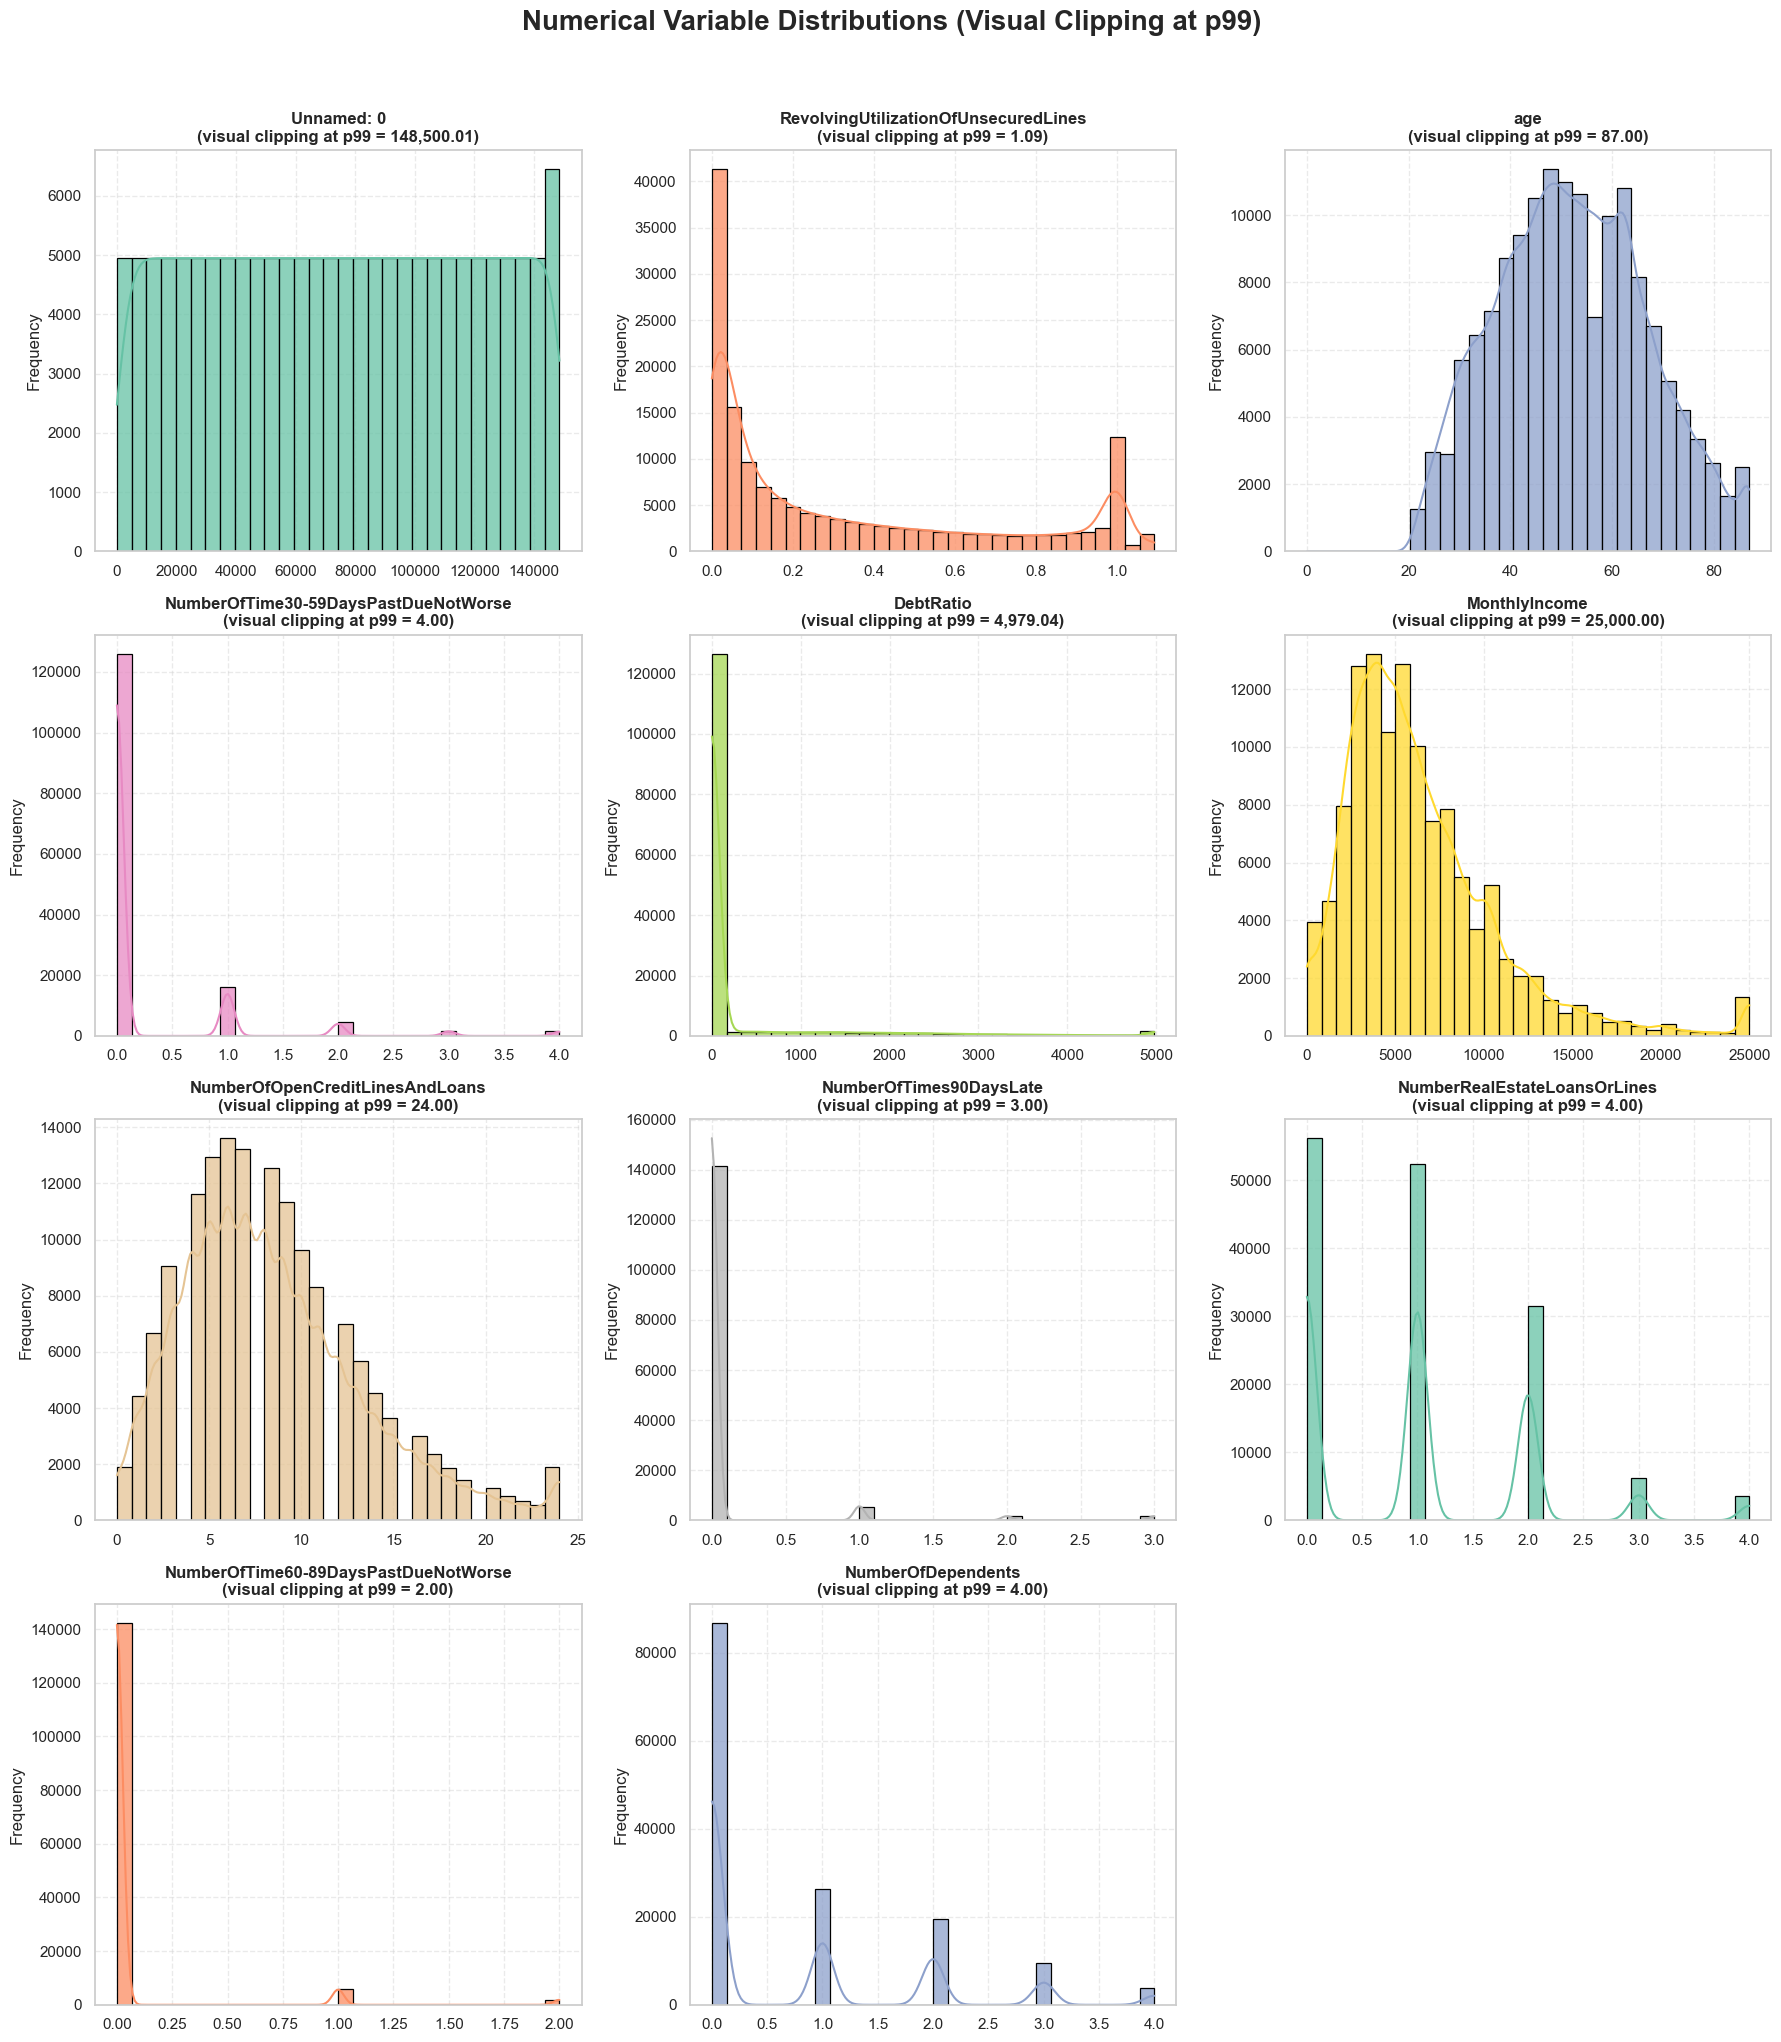

In [8]:
plot_numeric_distributions(
    df,
    target_column="SeriousDlqin2yrs",
    percentile=0.99
)

The numerical variables show highly heterogeneous distributions, which is common in credit risk datasets. Several financial variables, such as `DebtRatio`, `MonthlyIncome`, and `RevolvingUtilizationOfUnsecuredLines`, are strongly right-skewed and contain extreme values, while delinquency-related features are heavily concentrated at zero, reflecting the imbalance between low- and high-risk borrowers. To improve visualization and reduce the impact of outliers, distributions were visually clipped at the 99th percentile.The numerical variables exhibit diverse distribution patterns, which is typical in credit risk datasets. Financial variables such as `DebtRatio`, `MonthlyIncome`, and `RevolvingUtilizationOfUnsecuredLines` are highly right-skewed, with the presence of extreme values and long tails that may influence model stability if left untreated. In contrast, delinquency-related variables (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, and `NumberOfTime60-89DaysPastDueNotWorse`) are heavily concentrated around zero, indicating that most borrowers do not present severe payment delays, while a smaller group accumulates multiple delinquencies.

Variables related to customer profile and credit behavior, such as `age` and `NumberOfOpenCreditLinesAndLoans`, display more regular and interpretable distributions. Overall, the analysis highlights the existence of skewness, sparsity, and outliers across several predictors, reinforcing the importance of preprocessing techniques such as clipping, transformation, and robust scaling before model training. For visualization purposes, distributions were clipped at the 99th percentile to reduce the distortion caused by extreme observations.

## Distribution of the objective Variable

The target variable in this credit risk analysis represents the payment default status of customers. This is a binary variable, where the value 0 corresponds to customers who did not default (No Default) and the value 1 represents customers who failed to meet their financial obligations (Default). Analyzing its distribution is essential, as it helps to understand the level of class imbalance in the dataset and assess its potential impact on predictive modeling.

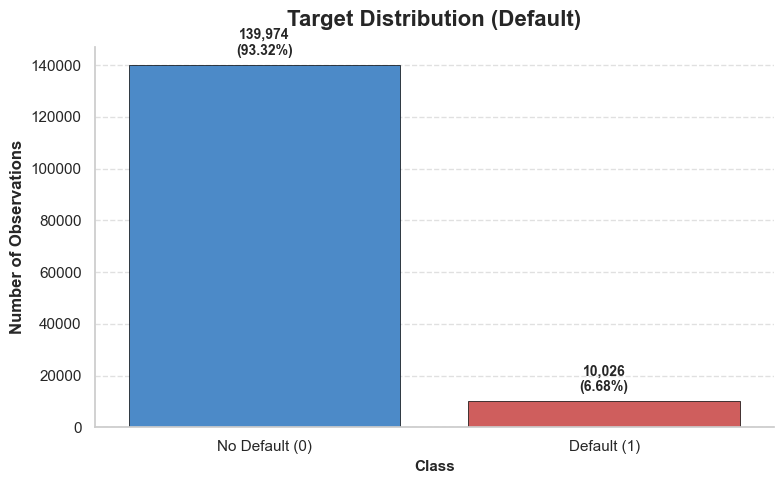

In [9]:
def plot_target_distribution(df, target_col="SeriousDlqin2yrs"):
    """
    Plot class distribution with counts and percentages.

    Parameters:
        df (pd.DataFrame): Input dataset
        target_col (str): Target column name
    """

    # --- Style setup ---
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 5))

    # --- Class count plot ---
    ax = sns.countplot(
        x=target_col,
        data=df,
        palette={"0": "#378ADD", "1": "#E24B4A"},  # numeric mapping
        edgecolor="black",
        linewidth=0.5
    )

    # --- Titles and labels ---
    plt.title(
        "Target Distribution (Default)",
        fontsize=16,
        fontweight="bold",
        pad=15
    )
    plt.xlabel("Class", fontsize=11, fontweight="bold")
    plt.ylabel("Number of Observations", fontsize=12, fontweight="bold")

    # --- Custom x-axis labels ---
    ax.set_xticklabels(["No Default (0)", "Default (1)"], fontsize=11)

    # --- Add count and percentage labels ---
    total = len(df)

    for patch in ax.patches:
        count = int(patch.get_height())
        pct = 100 * count / total

        ax.annotate(
            f"{count:,}\n({pct:.2f}%)",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points"
        )

    # --- Grid styling ---
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.xaxis.grid(False)

    # --- Clean spines ---
    sns.despine(left=False, bottom=False)

    plt.tight_layout()
    plt.show()

plot_target_distribution(df)

In [10]:
# Numerically %
df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

In [11]:
# Imbalance ratio
imbalance_ratio = df['SeriousDlqin2yrs'].value_counts()[0] / df['SeriousDlqin2yrs'].value_counts()[1]
print(f"Imbalance Ratio (No Default : Default) = {imbalance_ratio:.2f} : 1")

Imbalance Ratio (No Default : Default) = 13.96 : 1


The distribution of the target variable reveals a significant imbalance between the two classes. Out of the total observations, approximately 139,974 records (93.32%) correspond to non-default customers, while only 10,026 records (6.68%) represent customers in default. This pattern is common in credit risk problems, where default events are relatively rare compared to non-default cases. Such imbalance is an important consideration during model development, since machine learning algorithms may become biased toward the majority class. Therefore, techniques such as resampling, class weighting, or the use of specialized evaluation metrics may be necessary to ensure robust and reliable prediction performance for identifying potential default cases.

### Outlier Analysis

Outlier detection is particularly important in credit risk datasets, as financial variables often contain extreme observations that may distort statistical analysis and negatively impact model performance. The following analysis focuses on identifying unusually large or inconsistent values across key numerical features, with special attention to variables related to income, debt, and credit utilization.

OUTLIER ANALYSIS REPORT


,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Outliers,Outlier Percentage
RevolvingUtilizationOfUnsecuredLines,0.029867,0.559046,0.529179,-0.763901,1.352814,763.0,0.51
DebtRatio,0.175074,0.868254,0.693180,-0.864696,1.908024,31311.0,20.87
MonthlyIncome,3400.000000,8249.000000,4849.000000,-3873.500000,15522.500000,4879.0,4.06
NumberRealEstateLoansOrLines,0.000000,2.000000,2.000000,-3.000000,5.000000,793.0,0.53



Analyzing: RevolvingUtilizationOfUnsecuredLines


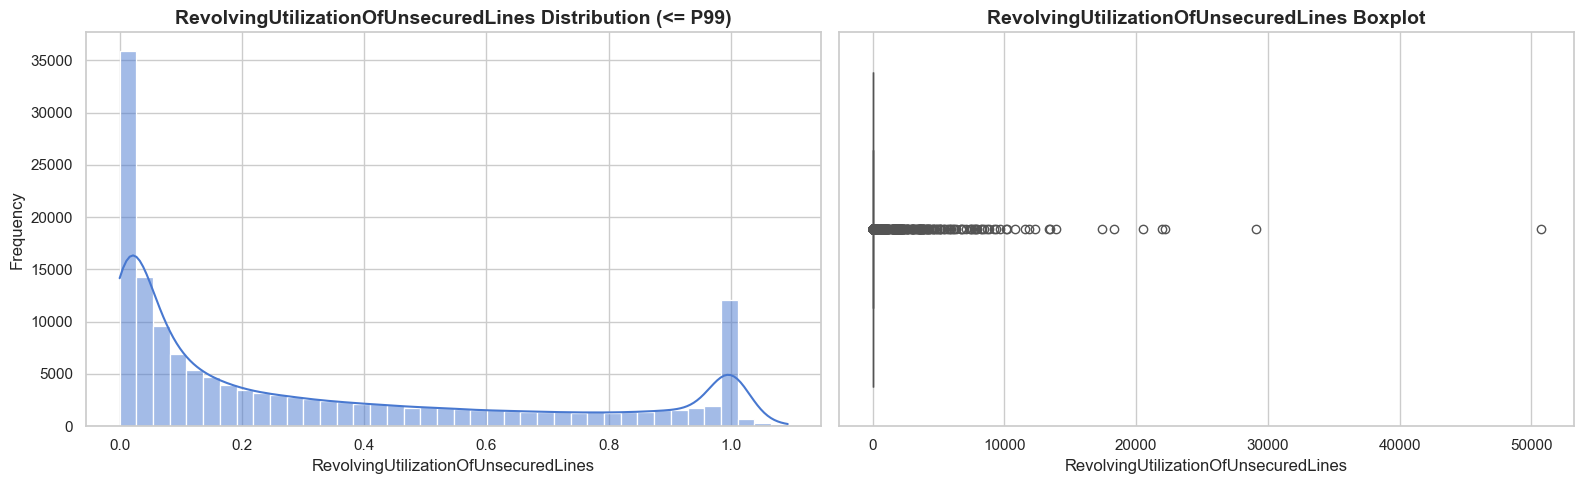


Analyzing: DebtRatio


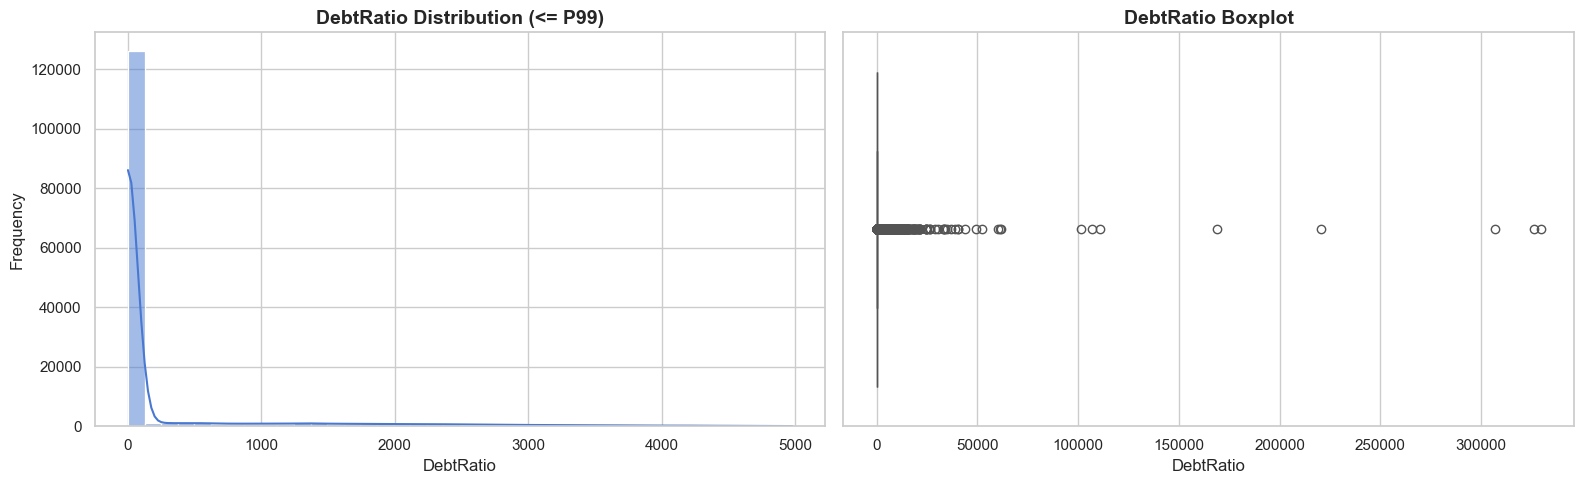


Analyzing: MonthlyIncome


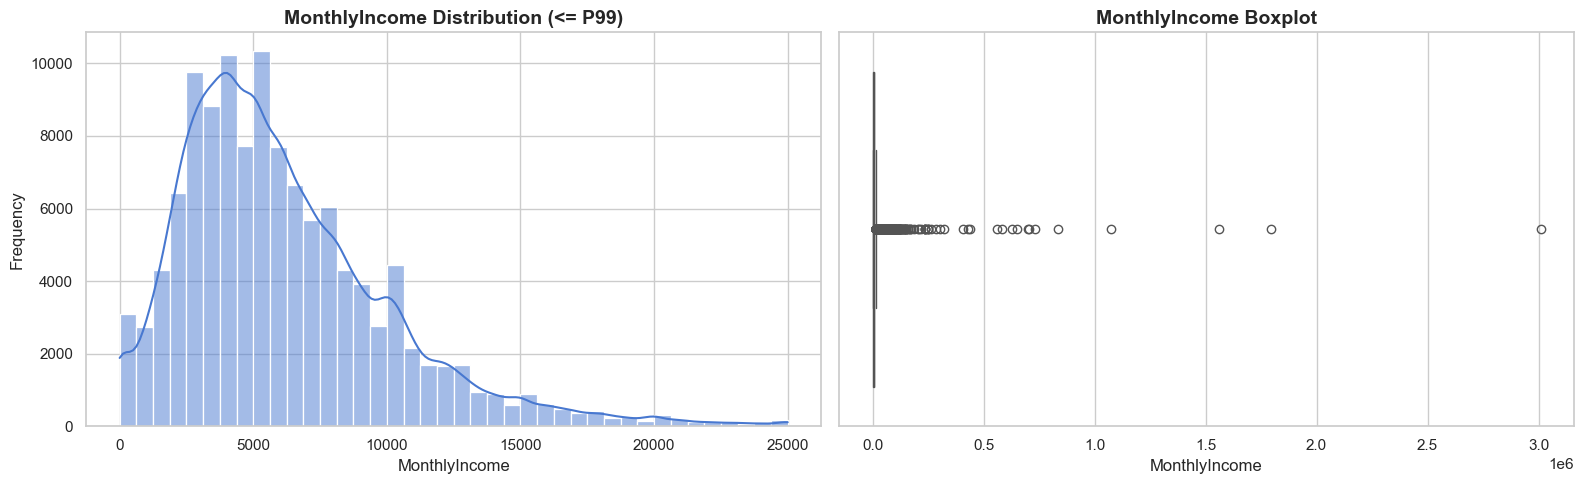


Analyzing: NumberRealEstateLoansOrLines


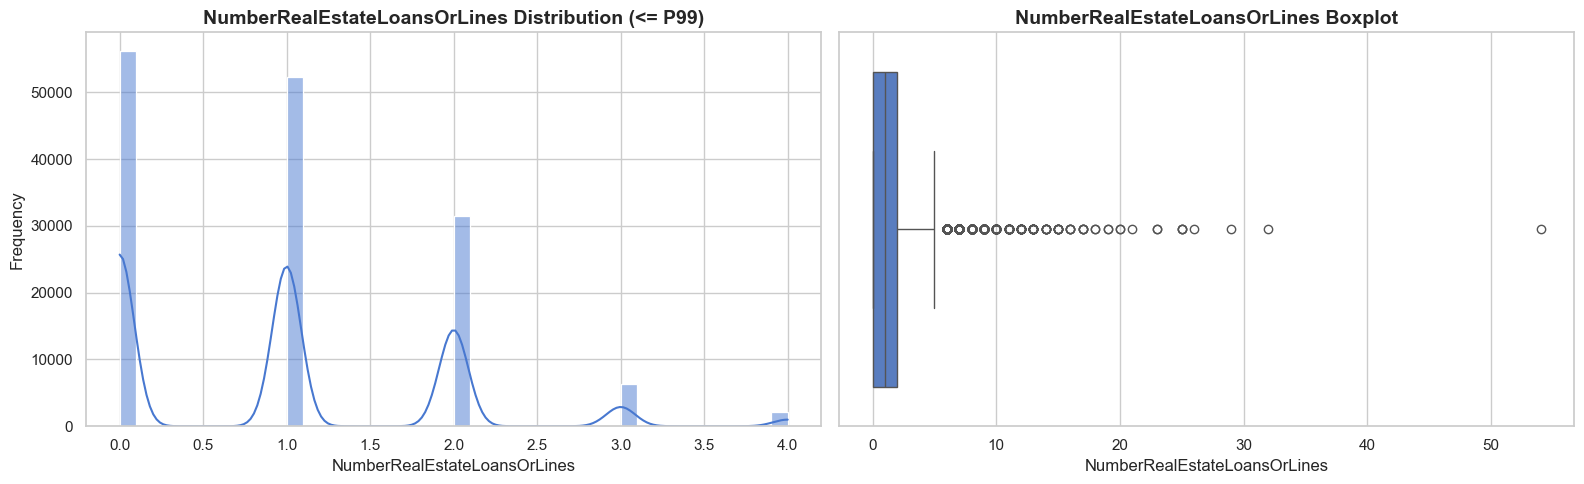

In [12]:
sns.set_theme(style="whitegrid", palette="muted")

OUTLIER_COLUMNS = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'NumberRealEstateLoansOrLines'
]

def calculate_outliers_iqr(series):
    """
    Detect outliers using the IQR method.
    """

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Total Outliers": len(outliers),
        "Outlier Percentage": round((len(outliers) / len(series)) * 100, 2)
    }


def plot_distribution_and_boxplot(df, column):
    """
    Plot histogram + KDE + boxplot for a feature.
    Histogram is capped at the 99th percentile for better visualization.
    """

    # Original series
    series = df[column].dropna()

    # Cut series at p99 ONLY for histogram visualization
    p99 = series.quantile(0.99)
    series_p99 = series[series <= p99]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 5)
    )

    # Histogram + KDE (using capped data)
    sns.histplot(
        series_p99,
        kde=True,
        bins=40,
        ax=axes[0]
    )

    axes[0].set_title(
        f'{column} Distribution (<= P99)',
        fontsize=14,
        fontweight='bold'
    )

    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    # Boxplot (using full data)
    sns.boxplot(
        x=series,
        ax=axes[1]
    )

    axes[1].set_title(
        f'{column} Boxplot',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


def outlier_summary_table(df, columns):
    """
    Generate a summary table with outlier statistics.
    """

    summary = {}

    for col in columns:
        summary[col] = calculate_outliers_iqr(df[col].dropna())

    return pd.DataFrame(summary).T


def analyze_outliers(df, columns):
    """
    Full outlier analysis pipeline.
    """

    print("=" * 70)
    print("OUTLIER ANALYSIS REPORT")
    print("=" * 70)

    # Statistical Summary
    summary_df = outlier_summary_table(df, columns)

    display(summary_df)

    # Visual Analysis
    for col in columns:

        print("\n" + "=" * 70)
        print(f'Analyzing: {col}')
        print("=" * 70)

        plot_distribution_and_boxplot(df, col)


analyze_outliers(df, OUTLIER_COLUMNS)

The analysis shows that `RevolvingUtilizationOfUnsecuredLines` is heavily concentrated between 0 and 1, consistent with its nature as a ratio, though extreme outliers suggest data entry errors. `DebtRatio` and `MonthlyIncome` follow typical income/debt patterns with the bulk of observations clustered at low values, but present extreme outliers reaching 300,000 and 3×10⁸ respectively, which are clearly anomalous. `NumberRealEstateLoansOrLines` shows a discrete distribution peaking at 0–2 loans, with a long tail extending to 40, which is implausible in a real-world credit. context.

## 📊 Data Preparation



### Column Unnamed: 0

In [13]:
# Column Unnamed: 0 is and index columns, we can drop it
df.drop(columns=["Unnamed: 0"], inplace=True)

### Age

To improve data quality and avoid unrealistic outliers, a filter is applied to the `age` variable, keeping only observations with ages between 18 and 100 years. This step helps ensure a more consistent and representative dataset for the credit risk analysis.

In [14]:
(df['age'] > 100).value_counts()


age
False    149987
True         13
Name: count, dtype: int64

In [15]:
(df['age'] < 18).value_counts()

age
False    149999
True          1
Name: count, dtype: int64

In [16]:
df = df[(df['age'] >= 18) & (df['age'] <= 100)]

There are only a few observations with `age` values below 18 or above 100. Since these cases represent a very small portion of the dataset and may correspond to unrealistic or inconsistent records, they can be removed without losing significant information. 

### Delinquency Features (30–59, 60–89, 90+ Days Past Due)

In this section, we review the distribution of the delinquency variables (30–59, 60–89, and 90+ days past due) in order to detect potential outliers, data entry errors, or unusual patterns. We use sorted value counts to inspect the consistency of the data before proceeding with further analysis.

In [17]:
df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126006
1      16032
2       4597
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [18]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142382
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [19]:
df['NumberOfTimes90DaysLate'].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141648
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

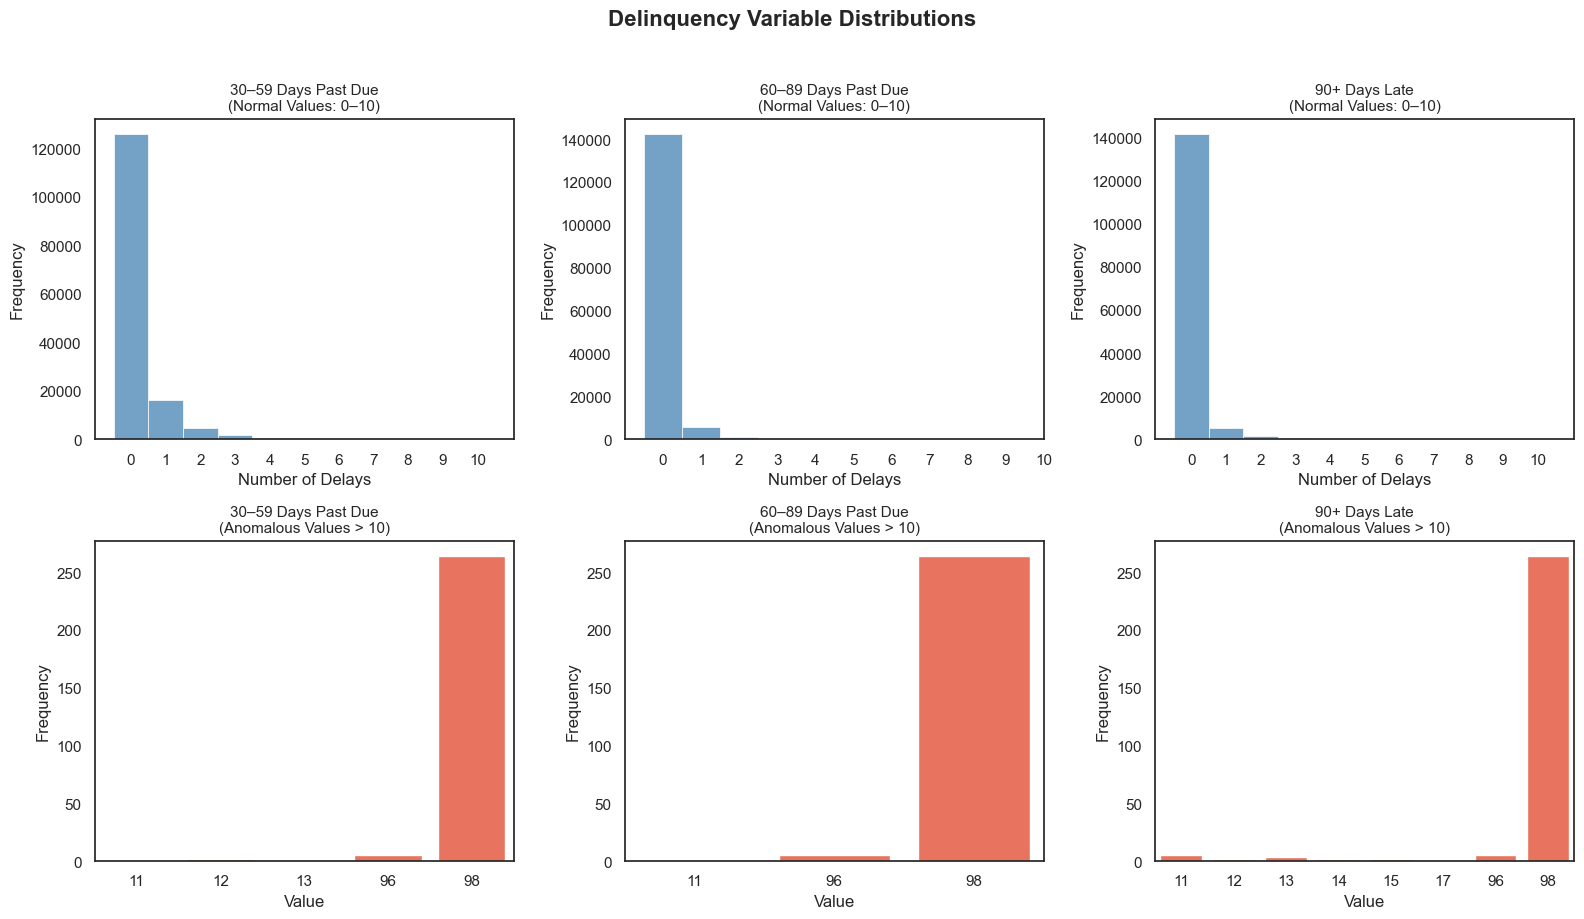

In [20]:
def plot_delinquency_distributions(
    df,
    columns,
    labels=None,
    threshold=10,
    figsize=(16, 9),
    normal_color="steelblue",
    anomaly_color="tomato"
):
    """
    Plot delinquency variable distributions separating
    normal values and anomalous values.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    columns : list
        List of delinquency columns.

    labels : list, optional
        Display names for columns.

    threshold : int, default=10
        Threshold used to separate normal vs anomalous values.

    figsize : tuple, default=(16, 9)
        Figure size.

    normal_color : str, default='steelblue'
        Color for normal distributions.

    anomaly_color : str, default='tomato'
        Color for anomalous distributions.
    """

    if labels is None:
        labels = columns

    sns.set_style("white")

    fig, axes = plt.subplots(2, len(columns), figsize=figsize)

    fig.suptitle(
        "Delinquency Variable Distributions",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    for i, (col, label) in enumerate(zip(columns, labels)):

        # -----------------------------------
        # Row 1: Normal values
        # -----------------------------------
        normal_values = df[df[col] <= threshold][col]

        sns.histplot(
            normal_values,
            bins=range(0, threshold + 2),
            discrete=True,
            ax=axes[0, i],
            color=normal_color,
            edgecolor="white",
            linewidth=0.5
        )

        axes[0, i].set_title(
            f"{label}\n(Normal Values: 0–{threshold})",
            fontsize=11
        )

        axes[0, i].set_xlabel("Number of Delays")
        axes[0, i].set_ylabel("Frequency")
        axes[0, i].set_xticks(range(0, threshold + 1))

        # -----------------------------------
        # Row 2: Anomalous values
        # -----------------------------------
        anomalies = (
            df[df[col] > threshold][col]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        anomalies.columns = ["value", "frequency"]

        sns.barplot(
            data=anomalies,
            x="value",
            y="frequency",
            ax=axes[1, i],
            color=anomaly_color,
            edgecolor="white"
        )

        axes[1, i].set_title(
            f"{label}\n(Anomalous Values > {threshold})",
            fontsize=11
        )

        axes[1, i].set_xlabel("Value")
        axes[1, i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

labels = [
    "30–59 Days Past Due",
    "60–89 Days Past Due",
    "90+ Days Late"
]

plot_delinquency_distributions(
    df,
    columns=delinquency_cols,
    labels=labels
)

In [21]:
df = df[(df['NumberOfTime30-59DaysPastDueNotWorse'] < 96) & (df['NumberOfTime60-89DaysPastDueNotWorse'] < 96) & (df['NumberOfTimes90DaysLate'] < 96)]

We observe some extreme values(96 and 98) that are clearly inconsistent with realistic delinquency behavior and are likely the result of data entry errors or placeholder codes. Therefore, we remove these observations to ensure data quality and improve the reliability of the subsequent modeling process.

# 🧩 Missing Values Analysis

Firstly, we identify missing values across all variables.

In [22]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29603
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3890
dtype: int64

                    n_missing  pct_missing
MonthlyIncome           29603        19.77
NumberOfDependents       3890         2.60


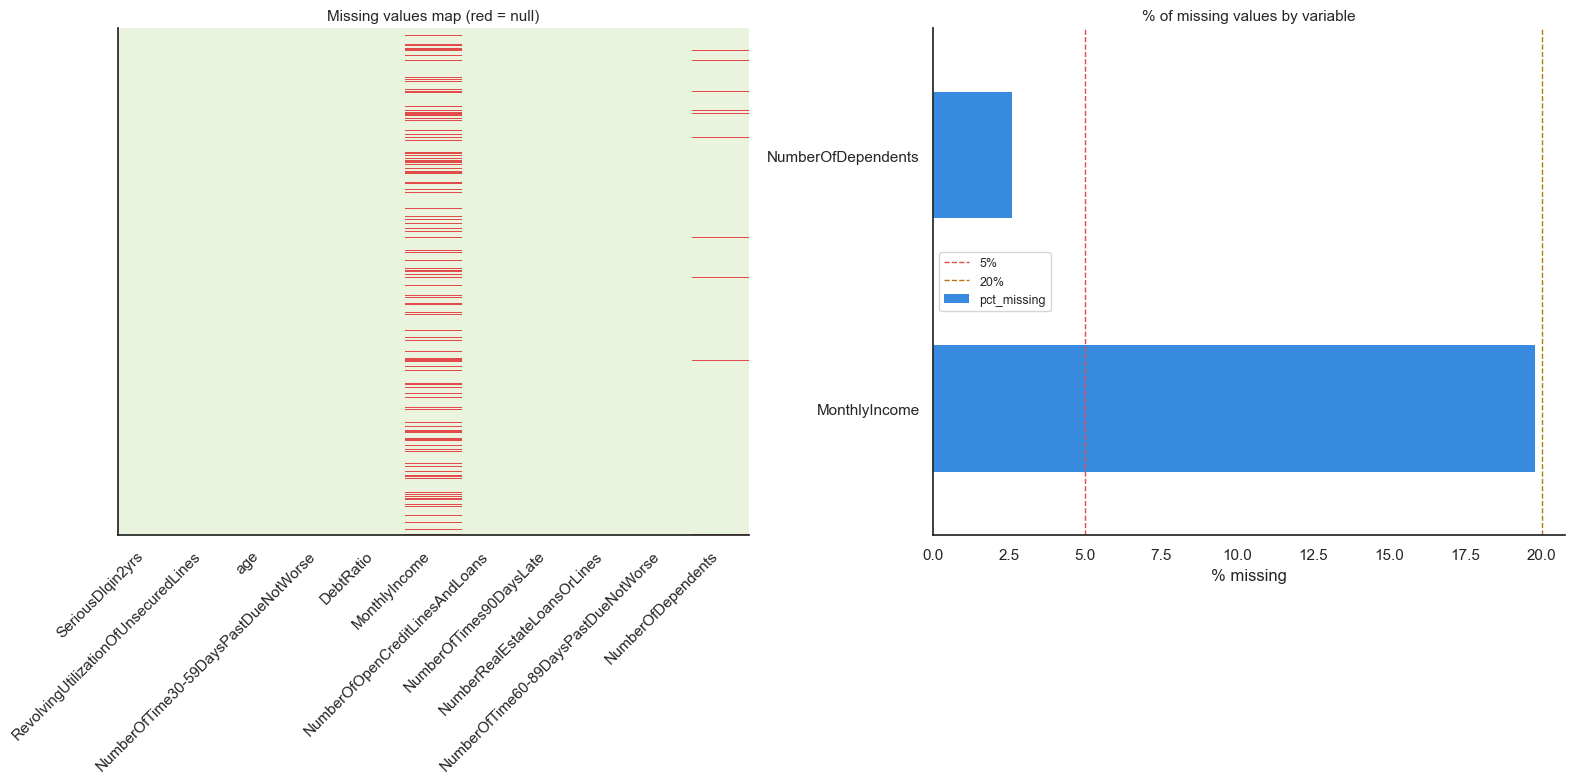


--- Missing values summary ---
                    n_missing  pct_missing
MonthlyIncome           29603        19.77
NumberOfDependents       3890         2.60


In [23]:
def missing_values_report(df):
    """
    Generate a missing values summary and visualization.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    Returns
    -------
    pd.DataFrame
        Summary table with missing counts and percentages.
    """

    # --- 1. Missing values summary ---
    missing = (
        pd.DataFrame({
            "n_missing": df.isnull().sum(),
            "pct_missing": df.isnull().mean() * 100
        })
        .query("n_missing > 0")
        .sort_values("pct_missing", ascending=False)
    )

    print(missing.round(2))

    # --- 2. Missing values visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Heatmap
    sns.heatmap(
        df.isnull(),
        cbar=False,
        yticklabels=False,
        cmap=["#EAF3DE", "#E24B4A"],
        ax=axes[0]
    )

    axes[0].set_title("Missing values map (red = null)", fontsize=11)
    axes[0].set_xticklabels(
        axes[0].get_xticklabels(),
        rotation=45,
        ha="right"
    )

    sns.despine(ax=axes[0])

    # Missing percentage bar chart
    missing["pct_missing"].plot(
        kind="barh",
        ax=axes[1],
        color="#378ADD",
        edgecolor="none"
    )

    axes[1].set_title("% of missing values by variable", fontsize=11)
    axes[1].set_xlabel("% missing")

    axes[1].axvline(
        5,
        color="#E24B4A",
        linestyle="--",
        linewidth=1,
        label="5%"
    )

    axes[1].axvline(
        20,
        color="#BA7517",
        linestyle="--",
        linewidth=1,
        label="20%"
    )

    axes[1].legend(fontsize=9)

    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.show()

    return missing.round(2)

missing = missing_values_report(df)
print("\n--- Missing values summary ---")
print(missing)

The dataset presents a relatively low level of missing data overall, concentrated mainly in `MonthlyIncome` and, to a lesser extent, `NumberOfDependents`. Since `MonthlyIncome` exceeds the 20% threshold, its treatment requires particular attention to avoid introducing bias during the preprocessing stage.

### MAR Check

To better understand the nature of the missing values, we evaluate whether the missingness pattern is related to the target variable (SeriousDlqin2yrs). For each variable containing missing values, a binary indicator is created to distinguish between observed and missing records, and the default rate is compared across both groups. This analysis helps identify whether the missingness could be informative and potentially associated with credit risk behavior.

In [24]:
def check_mar(df, missing_cols, target="SeriousDlqin2yrs"):
    """
    Evaluate whether the missingness pattern is related to the target variable.

    Parameters
    ----------
    df : pd.DataFrame
        Original dataframe.
    missing_cols : iterable
        Columns containing missing values.
    target : str
        Target variable.

    Returns
    -------
    pd.DataFrame
        Table with default rates for observed vs missing values.
    """

    mar_results = {}

    for col in missing_cols:
        missing_flag = f"missing_{col}"

        # Create missing indicator
        df[missing_flag] = df[col].isnull().astype(int)

        # Compute default rates
        rates = df.groupby(missing_flag)[target].mean()

        mar_results[col] = {
            "Default rate (observed)": rates.get(0, float("nan")),
            "Default rate (missing)": rates.get(1, float("nan")),
        }

    mar_check = pd.DataFrame(mar_results).T

    mar_check["difference"] = (
        mar_check["Default rate (missing)"]
        - mar_check["Default rate (observed)"]
    ).round(4)

    return mar_check.round(4)

mar_check = check_mar(df, missing.index)
print("\n--- MAR check: default rates ---")
print(mar_check)


--- MAR check: default rates ---
                    Default rate (observed)  Default rate (missing)  \
MonthlyIncome                        0.0689                  0.0543   
NumberOfDependents                   0.0666                  0.0429   

                    difference  
MonthlyIncome          -0.0146  
NumberOfDependents     -0.0237  


The missingness pattern suggests that the data is unlikely to be Missing Completely at Random (MCAR). 
For both `MonthlyIncome` and `NumberOfDependents`, the observed default rates differ between records 
with available values and records with missing values. 

In particular, customers with missing information exhibit lower default rates, which indicates that 
the probability of missingness may be related to underlying borrower characteristics or repayment behavior. 
This pattern is more consistent with a Missing At Random (MAR) mechanism, where missingness can be 
partially explained by other observed variables in the dataset.


### Number of Dependents

As we observed before, the `NumberOfDependents` feature contains missing values that must be handled before modeling. 
Since this variable represents a discrete count feature with a strongly concentrated distribution, 
analyzing its frequency distribution is essential to determine an appropriate imputation strategy.

In [25]:
df["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     86705
1.0     26292
2.0     19501
3.0      9479
4.0      2860
5.0       745
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

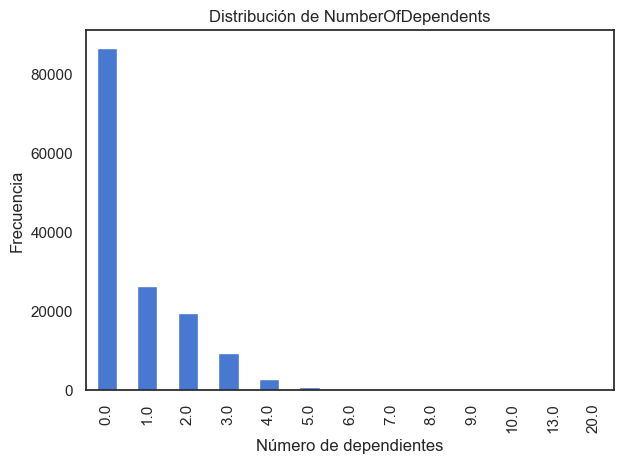

In [26]:
counts = df["NumberOfDependents"].value_counts().sort_index()

# Gráfica
plt.figure()
counts.plot(kind="bar")

plt.title("Distribución de NumberOfDependents")
plt.xlabel("Número de dependientes")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

The distribution shows that most borrowers report `0` dependents, making it the dominant category 
in the dataset. This suggests that imputing missing values with the mode is both statistically 
reasonable and consistent with the underlying distribution of the variable.

This approach is appropriate because the variable is discrete and highly concentrated around lower values, 
making the mode a robust and interpretable choice that preserves the overall distribution of the feature.

In [27]:
df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0], inplace=True)

**Monthly Income**        

Before handling this variable's missing values, it is important to identify potentially invalid observations. 
In the `MonthlyIncome` feature, several entries may contain a value of `0`, which doesn't represent  the
realistic borrower income levels in a credit risk context.

In [28]:
(df["MonthlyIncome"] == 0).sum()

np.int64(1627)

Some observations in `MonthlyIncome` contain a value of `0`, which is unlikely to represent a realistic 
monthly income in the context of credit risk analysis. 

Since it is unclear whether these zeros correspond to true values or missing information, they will be 
treated as missing values (`NaN`). This assumption is preferable because keeping artificial zeros could 
distort the distribution of the feature and negatively impact both statistical analysis and model performance.

In [29]:
df["MonthlyIncome"].replace(0, np.nan, inplace=True)
df["MonthlyIncome_missing"] = df.MonthlyIncome.isnull().astype(int)

In [30]:
# Describe MonthlyIncome    
df.MonthlyIncome.describe()

count    1.184870e+05
mean     6.767186e+03
std      1.446993e+04
min      1.000000e+00
25%      3.500000e+03
50%      5.447000e+03
75%      8.302000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

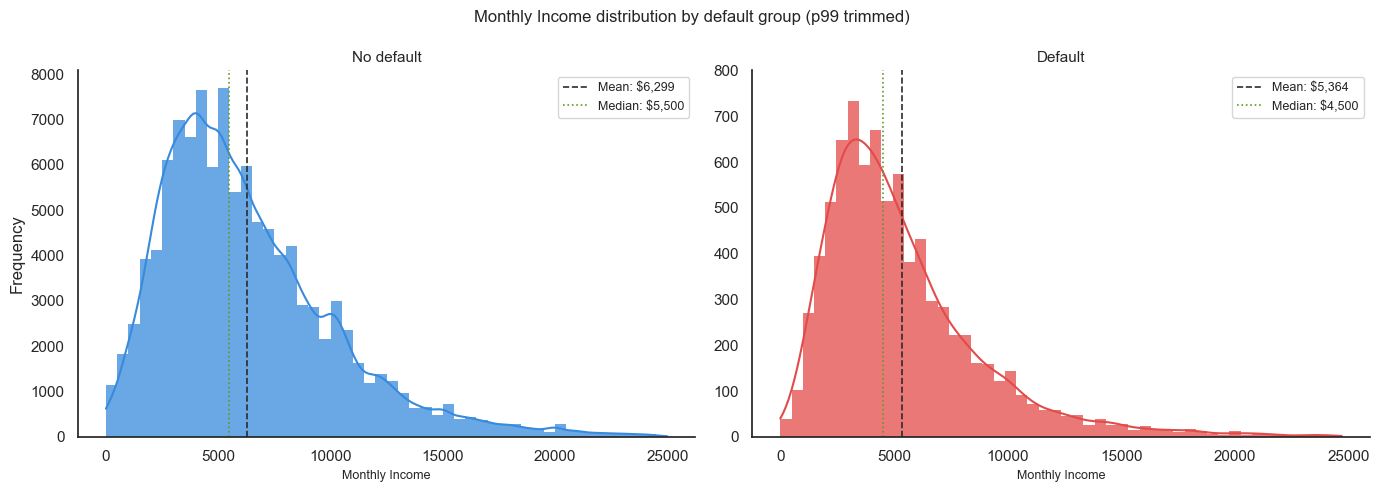

In [31]:
def plot_monthly_income_distribution(
    df,
    income_col="MonthlyIncome",
    target="SeriousDlqin2yrs",
    percentile=0.99
):
    """
    Plot the monthly income distribution by default group.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    income_col : str
        Income variable name.
    target : str
        Target variable name.
    percentile : float
        Upper percentile threshold used to remove outliers.

    Returns
    -------
    None
    """

    # Remove extreme outliers
    income_p = df[income_col].quantile(percentile)
    df_plot = df[df[income_col] < income_p]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    labels = {
        0: "No default",
        1: "Default"
    }

    colors = {
        0: "#378ADD",
        1: "#E24B4A"
    }

    for ax, (group, label) in zip(axes, labels.items()):

        data = df_plot[df_plot[target] == group][income_col]

        sns.histplot(
            data,
            bins=50,
            kde=True,
            color=colors[group],
            ax=ax,
            edgecolor="none",
            alpha=0.75,
            line_kws={"linewidth": 1.5}
        )

        # Mean line
        ax.axvline(
            data.mean(),
            color="#2C2C2A",
            linestyle="--",
            linewidth=1.2,
            label=f"Mean: ${data.mean():,.0f}"
        )

        # Median line
        ax.axvline(
            data.median(),
            color="#639922",
            linestyle=":",
            linewidth=1.2,
            label=f"Median: ${data.median():,.0f}"
        )

        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Monthly Income", fontsize=9)

        if group == 0:
            ax.set_ylabel("Frequency")
        else:
            ax.set_ylabel("")
            ax.set_ylim(0, 800)

        ax.legend(fontsize=9)

        sns.despine(ax=ax)

    plt.suptitle(
        "Monthly Income distribution by default group (p99 trimmed)",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

plot_monthly_income_distribution(df)

The previous missingness analysis suggested that `MonthlyIncome` follows a Missing At Random (MAR) 
mechanism, since the probability of missingness appears to be associated with the target variable 
(`SeriousDlqin2yrs`).

To account for this dependency, missing values were not imputed using a global statistic. Instead, 
the feature was first log-transformed using `log1p` in order to reduce skewness and mitigate the 
impact of extreme income values commonly observed in financial datasets.

After the transformation, missing values were imputed using the median income within each default group. 
This approach preserves differences between borrowers who defaulted and those who did not, resulting in 
a more realistic and statistically consistent imputation strategy.

In [32]:
# Log-transform 
df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"])

# Imputation
df["MonthlyIncome_log"] = df.groupby("SeriousDlqin2yrs")["MonthlyIncome_log"]\
                            .transform(lambda x: x.fillna(x.median()))

# # Verification
# print(df["MonthlyIncome_log"].isnull().sum())  # → 0
# print(df.groupby("SeriousDlqin2yrs")["MonthlyIncome_log"].median().round(3))

In [33]:
# Revert log
df["MonthlyIncome"] = np.expm1(df["MonthlyIncome_log"])

In [34]:
# Drop auxiliar columns
df = df.drop(columns=["missing_MonthlyIncome", "missing_NumberOfDependents"])

## 🔎 Data Inspection After Cleaning

In [35]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,MonthlyIncome_log
count,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,1.497170e+05,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000
mean,0.065978,6.058057,52.323524,0.245797,353.626931,6.491994e+03,8.468096,0.090464,1.020125,0.064829,0.738199,0.208594,8.543630
std,0.248244,249.991210,14.747223,0.697792,2039.678899,1.288413e+04,5.138154,0.485549,1.129976,0.330088,1.107402,0.406305,0.802139
min,0.000000,0.000000,21.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147
25%,0.000000,0.029776,41.000000,0.000000,0.176008,4.000000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.294300
50%,0.000000,0.153496,52.000000,0.000000,0.367118,5.500000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.612685
75%,0.000000,0.555614,63.000000,0.000000,0.869710,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,8.909370
max,1.000000,50708.000000,99.000000,13.000000,329664.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000,1.000000,14.917036


In [36]:
df.shape

(149717, 13)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149717 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149717 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149717 non-null  float64
 2   age                                   149717 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149717 non-null  int64  
 4   DebtRatio                             149717 non-null  float64
 5   MonthlyIncome                         149717 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149717 non-null  int64  
 7   NumberOfTimes90DaysLate               149717 non-null  int64  
 8   NumberRealEstateLoansOrLines          149717 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149717 non-null  int64  
 10  NumberOfDependents                    149717 non-null  float64
 11  Month

## 💾 Save cleaned data

In [ ]:
# # Save cleaned data
# df.to_csv(path / "cs-training-cleaned.csv", index=False)